In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, rc
from IPython.display import HTML
from scipy.signal import convolve2d
from scipy.optimize import curve_fit

In [2]:
plt.rcParams.update({'font.size': 20})
plt.rcParams.update({'lines.linewidth': 2})

def findMoment(arr,order,shift=0):
    # Shift i to i - 50
    shifted_indices = np.arange(len(arr)) - (len(arr)/2) - shift
    
    zero = arr[0]

    return np.sum(shifted_indices**order * (arr-np.min(arr))) / np.sum(arr-np.min(arr))
    # return np.sum(shifted_indices**order * (np.abs(arr-zero)) / np.sum(np.abs(arr-zero)))

## Correlation Diagonal Hopping Della

### pdr=0 pgen=0.01 Scan size check negatice value

100 * 100 * 2000 nsim=50, d1101-1110 => 1100

200 * 200 * 2000 nsim=10, d2101-2110 => 2100

200 * 200 * 1000 nsim=100, d2101-2110 => 3100

200 * 200 * 2000 nsim=1000, d2101-2110 => 4100

In [3]:
file_name = "../data/241210/241210_d3100"
raw = np.load(file_name+"_scoor_pp.npz")
x_l = raw["x_l"]
y_l = raw["y_l"]
t_l = raw["z_l"]
scoor = raw["data_ave_l"]
raw = np.load(file_name+"_pcoor_pp.npz")
pcoor = raw["data_ave_l"]
raw = np.load(file_name+"_ncoor_pp.npz")
ncoor = raw["data_ave_l"]

mid_lattice = int(len(x_l)/2)
print(len(x_l),len(y_l),len(t_l))

100 100 1000


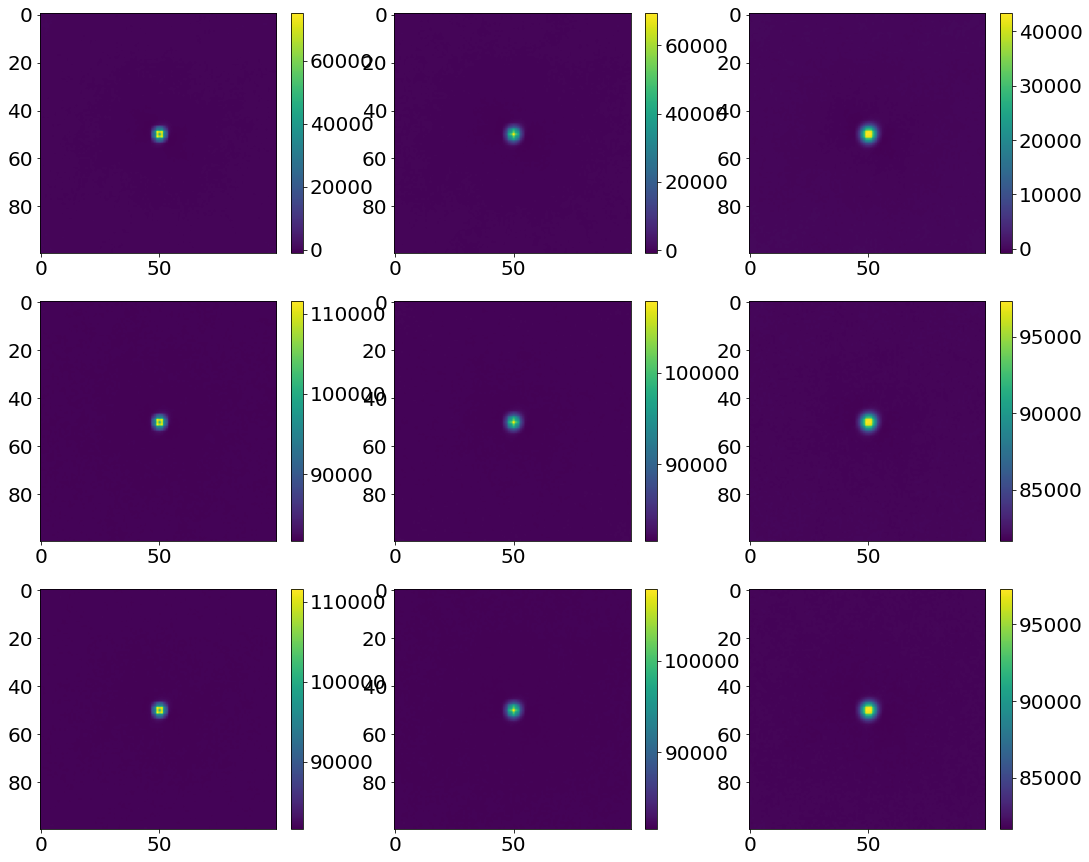

In [15]:
t1 = 3
t2 = 4
t3 = 5

plt.figure(figsize=(18,15))
plt.subplot(3,3,1)
scoor_r = np.roll(scoor[:,:,t1],(int(len(x_l)/2),int(len(y_l)/2)),(0,1)).T
plt.imshow(scoor_r,aspect='auto')
plt.colorbar()
plt.subplot(3,3,2)
scoor_r = np.roll(scoor[:,:,t2],(int(len(x_l)/2),int(len(y_l)/2)),(0,1)).T
plt.imshow(scoor_r,aspect='auto')
plt.colorbar()
plt.subplot(3,3,3)
scoor_r = np.roll(scoor[:,:,t3],(int(len(x_l)/2),int(len(y_l)/2)),(0,1)).T
plt.imshow(scoor_r,aspect='auto')
plt.colorbar()
plt.subplot(3,3,4)
pcoor_r = np.roll(pcoor[:,:,t1],(int(len(x_l)/2),int(len(y_l)/2)),(0,1)).T
plt.imshow(pcoor_r,aspect='auto')
plt.colorbar()
plt.subplot(3,3,5)
pcoor_r = np.roll(pcoor[:,:,t2],(int(len(x_l)/2),int(len(y_l)/2)),(0,1)).T
plt.imshow(pcoor_r,aspect='auto')
plt.colorbar()
plt.subplot(3,3,6)
pcoor_r = np.roll(pcoor[:,:,t3],(int(len(x_l)/2),int(len(y_l)/2)),(0,1)).T
plt.imshow(pcoor_r,aspect='auto')
plt.colorbar()
plt.subplot(3,3,7)
ncoor_r = np.roll(ncoor[:,:,t1],(int(len(x_l)/2),int(len(y_l)/2)),(0,1)).T
plt.imshow(ncoor_r,aspect='auto')
plt.colorbar()
plt.subplot(3,3,8)
ncoor_r = np.roll(ncoor[:,:,t2],(int(len(x_l)/2),int(len(y_l)/2)),(0,1)).T
plt.imshow(ncoor_r,aspect='auto')
plt.colorbar()
plt.subplot(3,3,9)
ncoor_r = np.roll(ncoor[:,:,t3],(int(len(x_l)/2),int(len(y_l)/2)),(0,1)).T
plt.imshow(ncoor_r,aspect='auto')
plt.colorbar()

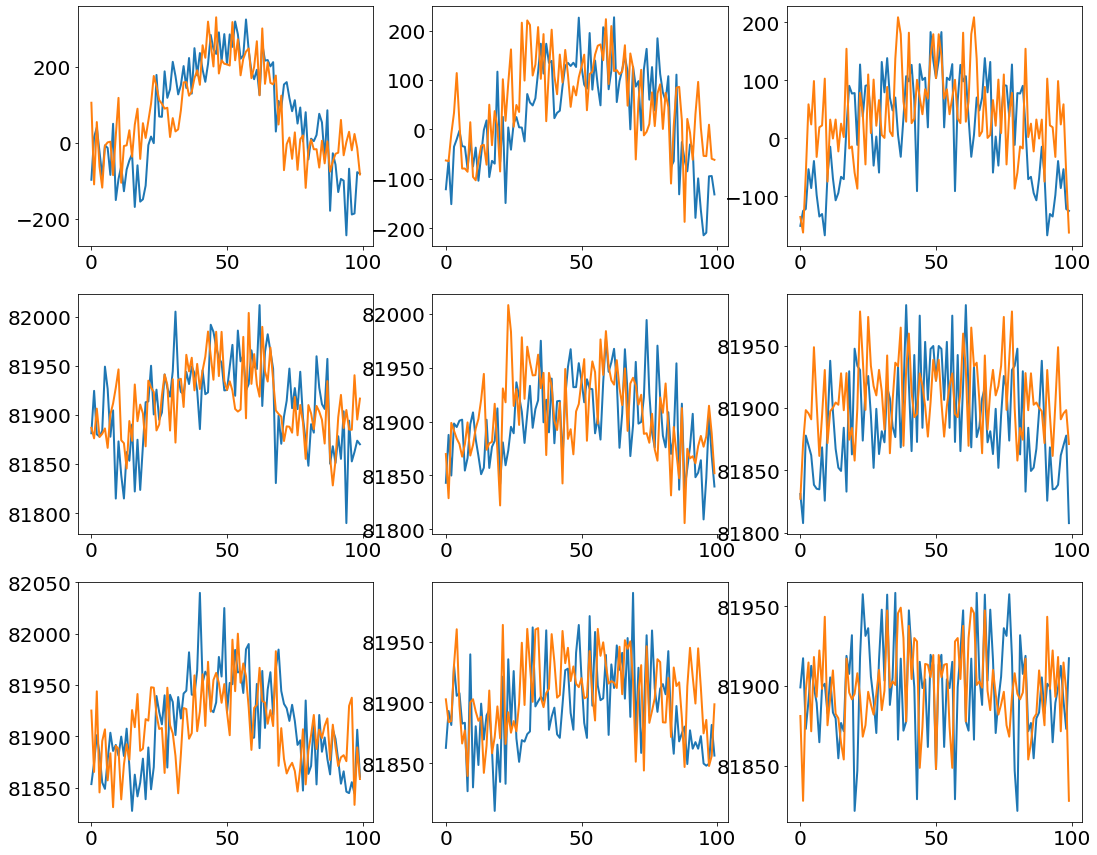

In [16]:
plt.figure(figsize=(18,15))
plt.subplot(3,3,1)
scoor_r = np.roll(scoor[:,:,t1],(int(len(x_l)/2),int(len(y_l)/2)),(0,1)).T
plt.plot(scoor_r[mid_lattice,:])
plt.plot(scoor_r[:,mid_lattice])
plt.subplot(3,3,2)
scoor_r = np.roll(scoor[:,:,t2],(int(len(x_l)/2),int(len(y_l)/2)),(0,1)).T
plt.plot(scoor_r[mid_lattice,:])
plt.plot(scoor_r[:,mid_lattice])
plt.subplot(3,3,3)
scoor_r = np.roll(scoor[:,:,t3],(int(len(x_l)/2),int(len(y_l)/2)),(0,1)).T
plt.plot(scoor_r[mid_lattice,:])
plt.plot(scoor_r[:,mid_lattice])
plt.subplot(3,3,4)
pcoor_r = np.roll(pcoor[:,:,t1],(int(len(x_l)/2),int(len(y_l)/2)),(0,1)).T
plt.plot(pcoor_r[mid_lattice,:])
plt.plot(pcoor_r[:,mid_lattice])
plt.subplot(3,3,5)
pcoor_r = np.roll(pcoor[:,:,t2],(int(len(x_l)/2),int(len(y_l)/2)),(0,1)).T
plt.plot(pcoor_r[mid_lattice,:])
plt.plot(pcoor_r[:,mid_lattice])
plt.subplot(3,3,6)
pcoor_r = np.roll(pcoor[:,:,t3],(int(len(x_l)/2),int(len(y_l)/2)),(0,1)).T
plt.plot(pcoor_r[mid_lattice,:])
plt.plot(pcoor_r[:,mid_lattice])
plt.subplot(3,3,7)
ncoor_r = np.roll(ncoor[:,:,t1],(int(len(x_l)/2),int(len(y_l)/2)),(0,1)).T
plt.plot(ncoor_r[mid_lattice,:])
plt.plot(ncoor_r[:,mid_lattice])
plt.subplot(3,3,8)
ncoor_r = np.roll(ncoor[:,:,t2],(int(len(x_l)/2),int(len(y_l)/2)),(0,1)).T
plt.plot(ncoor_r[mid_lattice,:])
plt.plot(ncoor_r[:,mid_lattice])
plt.subplot(3,3,9)
ncoor_r = np.roll(ncoor[:,:,t3],(int(len(x_l)/2),int(len(y_l)/2)),(0,1)).T
plt.plot(ncoor_r[mid_lattice,:])
plt.plot(ncoor_r[:,mid_lattice])

check negative value

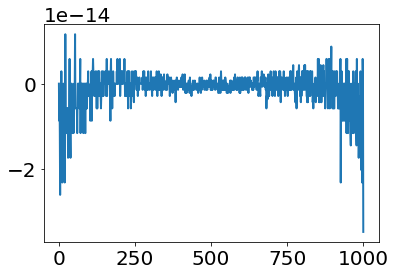

In [17]:
plt.plot(t_l,np.average(scoor[:,:,:],axis=(0,1)))

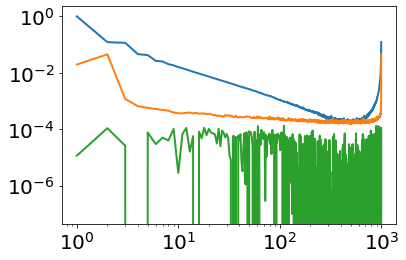

In [18]:
plt.plot(t_l,np.max(scoor[:,:,:],axis=(0,1)) / np.max(scoor[:,:,0],axis=(0,1)))
plt.plot(t_l,-np.min(scoor[:,:,:],axis=(0,1))/ np.max(scoor[:,:,0],axis=(0,1)))
plt.plot(t_l,(scoor[mid_lattice,mid_lattice,:]/ np.max(scoor[:,:,0],axis=(0,1))))
plt.xscale('log')
plt.yscale('log')

100 100 2000
200 200 2000


(100, 1000)

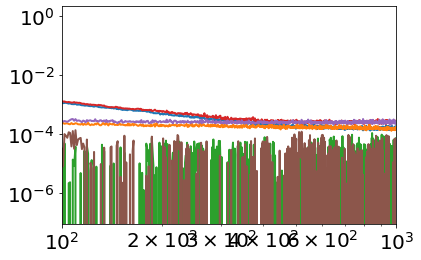

In [21]:
file_name = "../data/241210/241210_d1100"
raw = np.load(file_name+"_scoor_pp.npz")
x_l = raw["x_l"]
y_l = raw["y_l"]
t_l = raw["z_l"]
scoor = raw["data_ave_l"]
raw = np.load(file_name+"_pcoor_pp.npz")
pcoor = raw["data_ave_l"]
raw = np.load(file_name+"_ncoor_pp.npz")
ncoor = raw["data_ave_l"]

mid_lattice = int(len(x_l)/2)
print(len(x_l),len(y_l),len(t_l))

plt.plot(t_l,np.max(scoor[:,:,:],axis=(0,1)) / np.max(scoor[:,:,0],axis=(0,1)))
plt.plot(t_l,-np.min(scoor[:,:,:],axis=(0,1))/ np.max(scoor[:,:,0],axis=(0,1)))
plt.plot(t_l,(scoor[mid_lattice,mid_lattice,:]/ np.max(scoor[:,:,0],axis=(0,1))))
# plt.xscale('log')
plt.yscale('log')

file_name = "../data/241210/241210_d2100"
raw = np.load(file_name+"_scoor_pp.npz")
x_l = raw["x_l"]
y_l = raw["y_l"]
t_l = raw["z_l"]
scoor = raw["data_ave_l"]
raw = np.load(file_name+"_pcoor_pp.npz")
pcoor = raw["data_ave_l"]
raw = np.load(file_name+"_ncoor_pp.npz")
ncoor = raw["data_ave_l"]

mid_lattice = int(len(x_l)/2)
print(len(x_l),len(y_l),len(t_l))

plt.plot(t_l,np.max(scoor[:,:,:],axis=(0,1)) / np.max(scoor[:,:,0],axis=(0,1)))
plt.plot(t_l,-np.min(scoor[:,:,:],axis=(0,1))/ np.max(scoor[:,:,0],axis=(0,1)))
plt.plot(t_l,(scoor[mid_lattice,mid_lattice,:]/ np.max(scoor[:,:,0],axis=(0,1))))
plt.xscale('log')
plt.yscale('log')

plt.xlim([100,1000])

100 100 2000
100 100 2000


(100, 1000)

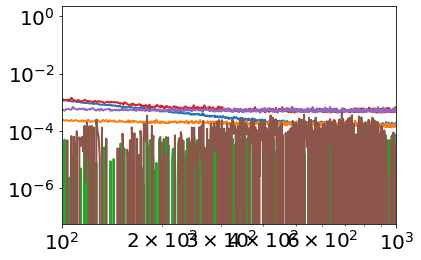

In [25]:
file_name = "../data/241210/241210_d1100"
raw = np.load(file_name+"_scoor_pp.npz")
x_l = raw["x_l"]
y_l = raw["y_l"]
t_l = raw["z_l"]
scoor = raw["data_ave_l"]
raw = np.load(file_name+"_pcoor_pp.npz")
pcoor = raw["data_ave_l"]
raw = np.load(file_name+"_ncoor_pp.npz")
ncoor = raw["data_ave_l"]

mid_lattice = int(len(x_l)/2)
print(len(x_l),len(y_l),len(t_l))

plt.plot(t_l,np.max(scoor[:,:,:],axis=(0,1)) / np.max(scoor[:,:,0],axis=(0,1)))
plt.plot(t_l,-np.min(scoor[:,:,:],axis=(0,1))/ np.max(scoor[:,:,0],axis=(0,1)))
plt.plot(t_l,(scoor[mid_lattice,mid_lattice,:]/ np.max(scoor[:,:,0],axis=(0,1))))
# plt.xscale('log')
plt.yscale('log')

file_name = "../data/241210/241210_d1101_"
x_l = np.loadtxt(file_name+'pcoor_scanx.csv',skiprows=1)
y_l = np.loadtxt(file_name+'pcoor_scany.csv',skiprows=1)
t_l = np.loadtxt(file_name+'pcoor_scanz.csv',skiprows=1)
# raw = np.loadtxt(file_name+'pcoor_data.csv',skiprows=1,delimiter=',')
# pcoor = raw.reshape((len(x_l),len(y_l),len(t_l)),order='F')
# raw = np.loadtxt(file_name+'ncoor_data.csv',skiprows=1,delimiter=',')
# ncoor = raw.reshape((len(x_l),len(y_l),len(t_l)),order='F')
raw = np.loadtxt(file_name+'scoor_data.csv',skiprows=1,delimiter=',')
scoor2 = raw.reshape((len(x_l),len(y_l),len(t_l)),order='F')

mid_lattice = int(len(x_l)/2)
print(len(x_l),len(y_l),len(t_l))

plt.plot(t_l,np.max(scoor2[:,:,:],axis=(0,1)) / np.max(scoor2[:,:,0],axis=(0,1)))
plt.plot(t_l,-np.min(scoor2[:,:,:],axis=(0,1))/ np.max(scoor2[:,:,0],axis=(0,1)))
plt.plot(t_l,(scoor2[mid_lattice,mid_lattice,:]/ np.max(scoor2[:,:,0],axis=(0,1))))
plt.xscale('log')
plt.yscale('log')

plt.xlim([100,1000])

find moment along the parallel cut

In [10]:
tm_l = np.arange(10,500)
m1_l = np.zeros(tm_l.shape)
m2_l = np.zeros(tm_l.shape)
m3_l = np.zeros(tm_l.shape)
m4_l = np.zeros(tm_l.shape)
m5_l = np.zeros(tm_l.shape)
m6_l = np.zeros(tm_l.shape)
m7_l = np.zeros(tm_l.shape)
m8_l = np.zeros(tm_l.shape)

for idx, tm in enumerate(tm_l):
    scoor_r = np.roll(scoor[:,:,tm],(int(len(x_l)/2),int(len(y_l)/2)),(0,1)).T
    m1_l[idx] = findMoment(scoor_r[:,mid_lattice],1)
    m2_l[idx] = findMoment(scoor_r[:,mid_lattice],2,shift=m1_l[idx])
    m3_l[idx] = findMoment(scoor_r[:,mid_lattice],3,shift=m1_l[idx])
    m4_l[idx] = findMoment(scoor_r[:,mid_lattice],4,shift=m1_l[idx])
    m5_l[idx] = findMoment(scoor_r[:,mid_lattice],5,shift=m1_l[idx])
    m6_l[idx] = findMoment(scoor_r[:,mid_lattice],6,shift=m1_l[idx])
    m7_l[idx] = findMoment(scoor_r[:,mid_lattice],7,shift=m1_l[idx])
    m8_l[idx] = findMoment(scoor_r[:,mid_lattice],8,shift=m1_l[idx])

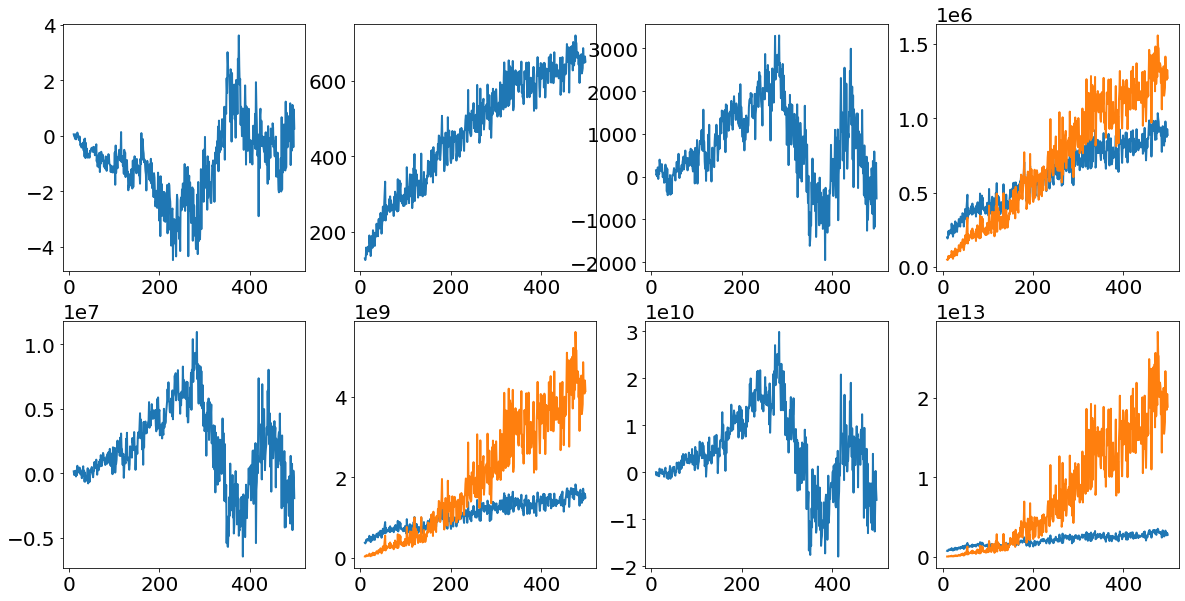

In [11]:
plt.figure(figsize=(20,10))
plt.subplot(2,4,1)
plt.plot(tm_l,m1_l)
plt.subplot(2,4,2)
plt.plot(tm_l,m2_l)
plt.subplot(2,4,3)
plt.plot(tm_l,m3_l)
plt.subplot(2,4,4)
plt.plot(tm_l,m4_l)
plt.plot(tm_l,3*m2_l**2)
plt.subplot(2,4,5)
plt.plot(tm_l,m5_l)
plt.subplot(2,4,6)
plt.plot(tm_l,m6_l)
plt.plot(tm_l,15*m2_l**3)
plt.subplot(2,4,7)
plt.plot(tm_l,m7_l)
plt.subplot(2,4,8)
plt.plot(tm_l,m8_l)
plt.plot(tm_l,105*m2_l**4)

moment along the prependicular cut

In [19]:
tm_l = np.arange(10,500)
m1_l = np.zeros(tm_l.shape)
m2_l = np.zeros(tm_l.shape)
m3_l = np.zeros(tm_l.shape)
m4_l = np.zeros(tm_l.shape)
m5_l = np.zeros(tm_l.shape)
m6_l = np.zeros(tm_l.shape)
m7_l = np.zeros(tm_l.shape)
m8_l = np.zeros(tm_l.shape)

for idx, tm in enumerate(tm_l):
    scoor_r = np.roll(scoor[:,:,tm],(int(len(x_l)/2),int(len(y_l)/2)),(0,1)).T
    m1_l[idx] = findMoment(scoor_r[mid_lattice,:],1)
    m2_l[idx] = findMoment(scoor_r[mid_lattice,:],2,shift=m1_l[idx])
    m3_l[idx] = findMoment(scoor_r[mid_lattice,:],3,shift=m1_l[idx])
    m4_l[idx] = findMoment(scoor_r[mid_lattice,:],4,shift=m1_l[idx])
    m5_l[idx] = findMoment(scoor_r[mid_lattice,:],5,shift=m1_l[idx])
    m6_l[idx] = findMoment(scoor_r[mid_lattice,:],6,shift=m1_l[idx])
    m7_l[idx] = findMoment(scoor_r[mid_lattice,:],7,shift=m1_l[idx])
    m8_l[idx] = findMoment(scoor_r[mid_lattice,:],8,shift=m1_l[idx])

100 100
-155.94000000000005 -202.17999999999998


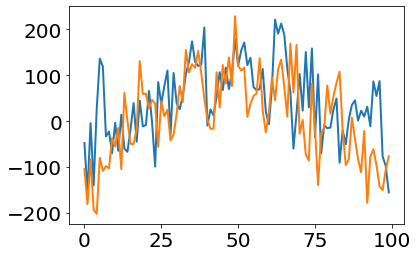

In [20]:
plt.plot(scoor_r[:,mid_lattice])
plt.plot(scoor_r[mid_lattice,:])
print(len(scoor_r[:,mid_lattice]),len(scoor_r[mid_lattice,:]))
print(np.min(scoor_r[:,mid_lattice]),np.min(scoor_r[mid_lattice,:]))

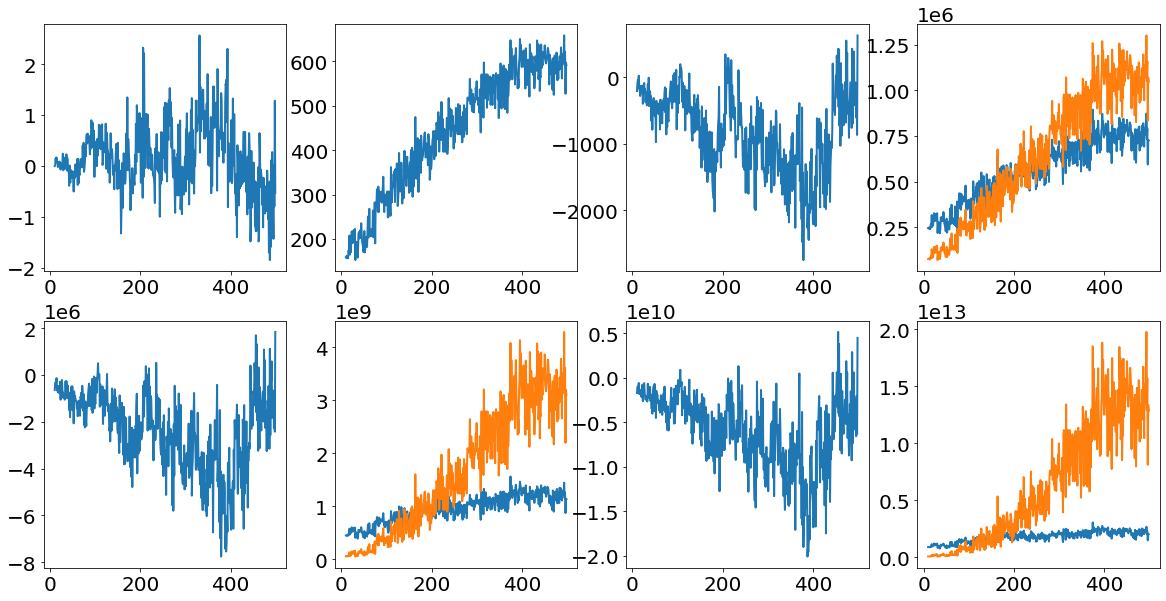

In [21]:
plt.figure(figsize=(20,10))
plt.subplot(2,4,1)
plt.plot(tm_l,m1_l)
plt.subplot(2,4,2)
plt.plot(tm_l,m2_l)
plt.subplot(2,4,3)
plt.plot(tm_l,m3_l)
plt.subplot(2,4,4)
plt.plot(tm_l,m4_l)
plt.plot(tm_l,3*m2_l**2)
plt.subplot(2,4,5)
plt.plot(tm_l,m5_l)
plt.subplot(2,4,6)
plt.plot(tm_l,m6_l)
plt.plot(tm_l,15*m2_l**3)
plt.subplot(2,4,7)
plt.plot(tm_l,m7_l)
plt.subplot(2,4,8)
plt.plot(tm_l,m8_l)
plt.plot(tm_l,105*m2_l**4)

test charge neutrality

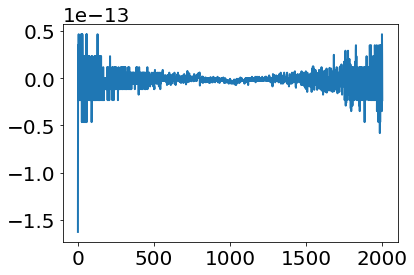

In [9]:
plt.plot(t_l,np.average(scoor[:,:,:],axis=(0,1)))

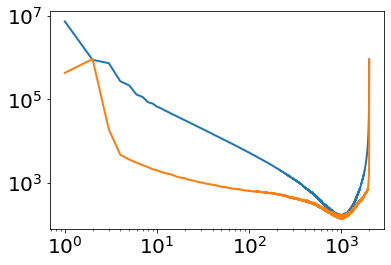

In [30]:
plt.plot(t_l,np.max(scoor[:,:,:],axis=(0,1)))
plt.plot(t_l,-np.min(scoor[:,:,:],axis=(0,1)))
plt.xscale('log')
# plt.xlim([0,1000])
plt.yscale('log')

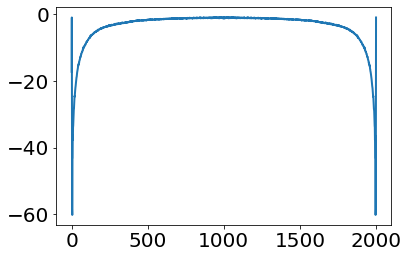

In [12]:
plt.plot(t_l,np.max(scoor[:,:,:],axis=(0,1))/np.min(scoor[:,:,:],axis=(0,1)))

## Quasi-1D Check Negative values
3 * 800 * 3000, pgen=0.01, T=1000 nsim=5000, 11101-11110 => 11100

3 * 1600 * 6000, pgen=0.01, T=1000 nsim=5000, 12101-12110 => 12100

In [4]:
file_name = "../data/241210/241210_d12100"
raw = np.load(file_name+"_scoor_pp.npz")
x_l = raw["x_l"]
y_l = raw["y_l"]
t_l = raw["z_l"]
scoor = raw["data_ave_l"]
raw = np.load(file_name+"_pcoor_pp.npz")
pcoor = raw["data_ave_l"]
raw = np.load(file_name+"_ncoor_pp.npz")
ncoor = raw["data_ave_l"]

mid_lattice = int(len(x_l)/2)
print(len(x_l),len(y_l),len(t_l))

3 1600 6000


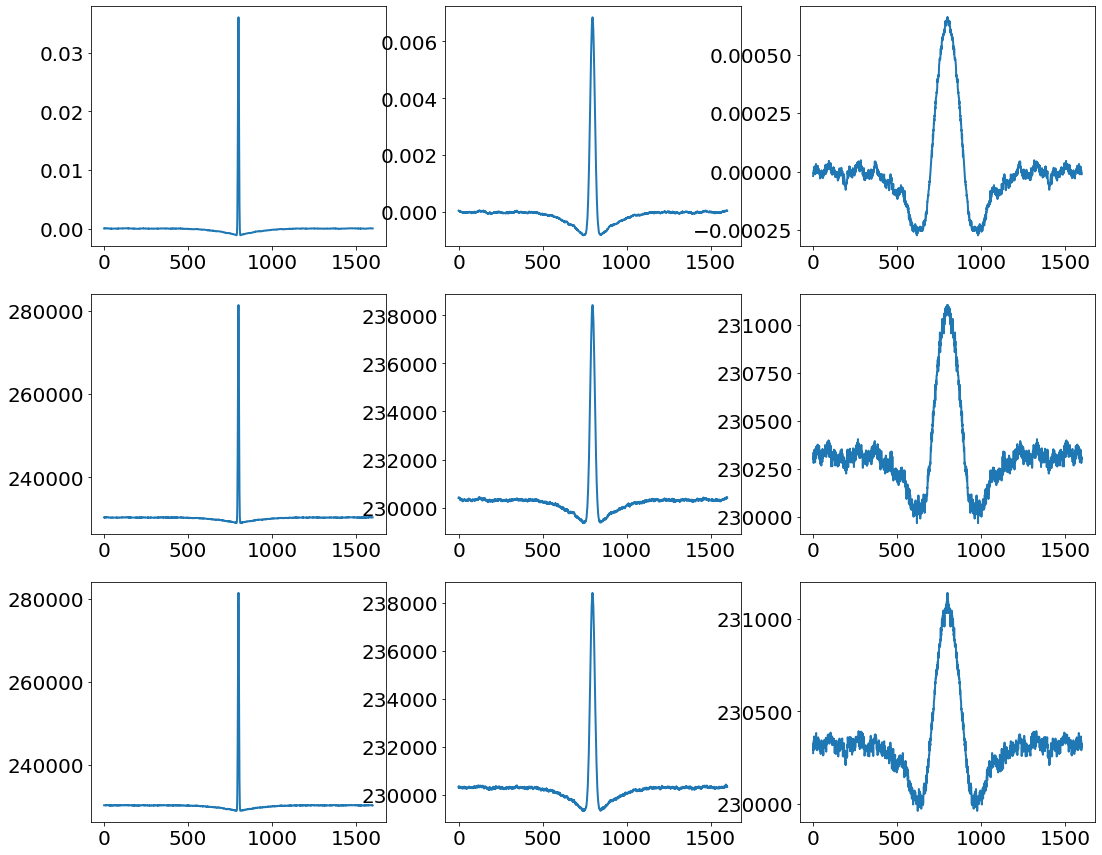

In [30]:
t1 = 10
t2 = 200
t3 = 3000
plt.figure(figsize=(18,15))
plt.subplot(3,3,1)
scoor_r = np.roll(scoor[:,:,t1],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.plot(scoor_r[1,:] / np.max(scoor[:,:,0]))
plt.subplot(3,3,2)
scoor_r = np.roll(scoor[:,:,t2],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.plot(scoor_r[1,:] / np.max(scoor[:,:,0]))
plt.subplot(3,3,3)
scoor_r = np.roll(scoor[:,:,t3],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.plot(scoor_r[1,:] / np.max(scoor[:,:,0]))
plt.subplot(3,3,4)
pcoor_r = np.roll(pcoor[:,:,t1],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.plot(pcoor_r[1,:])
plt.subplot(3,3,5)
pcoor_r = np.roll(pcoor[:,:,t2],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.plot(pcoor_r[1,:])
plt.subplot(3,3,6)
pcoor_r = np.roll(pcoor[:,:,t3],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.plot(pcoor_r[1,:])
plt.subplot(3,3,7)
ncoor_r = np.roll(ncoor[:,:,t1],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.plot(ncoor_r[1,:])
plt.subplot(3,3,8)
ncoor_r = np.roll(ncoor[:,:,t2],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.plot(ncoor_r[1,:])
plt.subplot(3,3,9)
ncoor_r = np.roll(ncoor[:,:,t3],(int(len(x_l)/2),int(len(y_l)/2)),(0,1))
plt.plot(ncoor_r[1,:])

check negative value

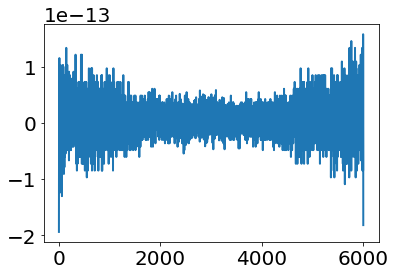

In [23]:
plt.plot(t_l,np.average(scoor[:,:,:],axis=(0,1)))

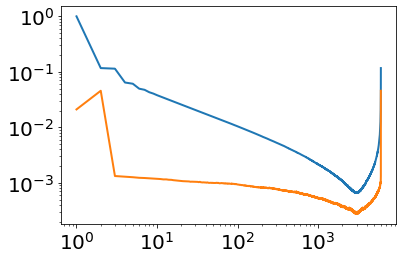

In [24]:
plt.plot(t_l,np.max(scoor[:,:,:],axis=(0,1)) / np.max(scoor[:,:,0],axis=(0,1)))
plt.plot(t_l,-np.min(scoor[:,:,:],axis=(0,1))/ np.max(scoor[:,:,0],axis=(0,1)))
# plt.plot(t_l,(scoor[mid_lattice,mid_lattice,:]/ np.max(scoor[:,:,0],axis=(0,1))))
plt.xscale('log')
plt.yscale('log')

3 800 3000
3 1600 6000


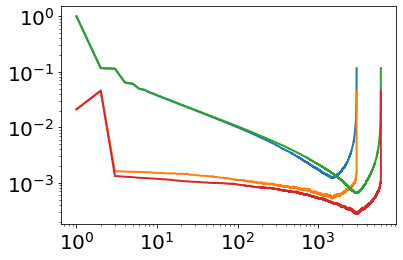

In [29]:
file_name = "../data/241210/241210_d11100"
raw = np.load(file_name+"_scoor_pp.npz")
x_l = raw["x_l"]
y_l = raw["y_l"]
t_l = raw["z_l"]
scoor = raw["data_ave_l"]
mid_lattice = int(len(x_l)/2)
print(len(x_l),len(y_l),len(t_l))

plt.plot(t_l,np.max(scoor[:,:,:],axis=(0,1)) / np.max(scoor[:,:,0],axis=(0,1)))
plt.plot(t_l,-np.min(scoor[:,:,:],axis=(0,1))/ np.max(scoor[:,:,0],axis=(0,1)))
# plt.plot(t_l,(scoor[1,1,:]/ np.max(scoor[:,:,0],axis=(0,1))))

file_name = "../data/241210/241210_d12100"
raw = np.load(file_name+"_scoor_pp.npz")
x_l = raw["x_l"]
y_l = raw["y_l"]
t_l = raw["z_l"]
scoor = raw["data_ave_l"]
mid_lattice = int(len(x_l)/2)
print(len(x_l),len(y_l),len(t_l))

plt.plot(t_l,np.max(scoor[:,:,:],axis=(0,1)) / np.max(scoor[:,:,0],axis=(0,1)))
plt.plot(t_l,-np.min(scoor[:,:,:],axis=(0,1))/ np.max(scoor[:,:,0],axis=(0,1)))
# plt.plot(t_l,(scoor[1,1,:]/ np.max(scoor[:,:,0],axis=(0,1))))
plt.xscale('log')
plt.yscale('log')